# Day 18 — Regression: Ensemble Regression and Prediction Intervals
## Week 2: Regression | Digital Consumer Platform Analytics

---

### Learning Objectives
- Understand GBR vs Random Forest for regression — when each wins
- Know regression loss functions: L2, L1, Huber — and when each is appropriate
- Derive conformal prediction intervals — model-agnostic uncertainty quantification
- Understand quantile regression forests
- Apply SHAP to regression models — interaction effects

---

### Dataset
**UCI Online Retail II** — LTV prediction continued.

---

## Part 1: Theory

### 18.1 Regression Loss Functions

**L2 Loss (Mean Squared Error):**
$$L(y, \hat{y}) = (y - \hat{y})^2$$

- Gradient: $2(y - \hat{y})$ — proportional to residual size
- GBM with L2 = GBM fitting ordinary residuals
- Sensitive to outliers: squares large errors

**L1 Loss (Mean Absolute Error):**
$$L(y, \hat{y}) = |y - \hat{y}|$$

- Gradient: $\text{sign}(y - \hat{y})$ — constant magnitude regardless of residual size
- More robust to outliers — doesn't square large errors
- Non-differentiable at 0 — requires subgradient methods

**Huber Loss (compromise):**
$$L(y, \hat{y}) = \begin{cases} \frac{1}{2}(y-\hat{y})^2 & \text{if } |y-\hat{y}| \leq \delta \\ \delta(|y-\hat{y}| - \frac{\delta}{2}) & \text{otherwise} \end{cases}$$

- Quadratic for small errors (like L2)
- Linear for large errors (like L1)
- Best of both: smooth gradient + outlier robustness
- $\delta$ controls the transition point

**LTV data context:** Customer LTV is typically right-skewed with a few very high spenders. Huber or L1 loss is more appropriate than L2 — prevents the high-LTV customers from dominating the gradient.

---

### 18.2 GBR vs Random Forest Regressor

| Property | GBR | RF Regressor |
|----------|-----|-------------|
| Bias | Low (iteratively reduced) | Moderate |
| Variance | Low (shrinkage) | Low (averaging) |
| Overfitting | High (needs tuning) | Moderate |
| Extrapolation | ❌ Tree-based, can't extrapolate | ❌ Same |
| Outlier sensitivity | Depends on loss function | Moderate |
| Feature interactions | ✅ Captures well | ✅ Captures well |
| Training speed | Slower (sequential) | Faster (parallel) |
| Interpretability | SHAP values | Feature importance |

**GBR typically wins when:** Data is large, relationships are complex, you can tune hyperparameters.
**RF typically wins when:** You need a quick baseline, data is small, interpretability matters more than accuracy.

---

### 18.3 Conformal Prediction Intervals

Traditional confidence intervals assume model specification is correct. Conformal prediction makes no distributional assumptions — it is **model-agnostic**.

**Algorithm (split conformal prediction):**

1. Split training set into proper training set and calibration set
2. Train model on proper training set
3. For each calibration point: compute conformity score $\alpha_i = |y_i - \hat{y}_i|$ (absolute residual)
4. For coverage level $1-\delta$ (e.g. 90%): find the $\lceil(1-\delta)(n_{cal}+1)\rceil/n_{cal}$ quantile of conformity scores:
   $$q = \text{Quantile}_{1-\delta}(\alpha_1, ..., \alpha_{n_{cal}})$$
5. For new test point $x$: prediction interval = $[\hat{y} - q, \hat{y} + q]$

**Coverage guarantee:** The true $y$ falls inside the interval at least $1-\delta$ fraction of the time — for any model, any data distribution.

**Limitation:** Fixed-width intervals. Doesn't adapt to local uncertainty (same width for dense and sparse regions).

**Adaptive conformal prediction:** Use normalized conformity scores $\alpha_i = |y_i - \hat{y}_i| / \hat{\sigma}_i$ where $\hat{\sigma}_i$ is a local uncertainty estimate. Produces variable-width intervals.

---

### 18.4 Quantile Regression Forests

Instead of predicting the mean response, predict any quantile directly.

For quantile $\tau \in (0,1)$: minimize pinball loss:
$$L_\tau(y, \hat{y}) = \begin{cases} \tau(y - \hat{y}) & \text{if } y \geq \hat{y} \\ (1-\tau)(\hat{y} - y) & \text{if } y < \hat{y} \end{cases}$$

For Random Forest: the conditional quantile is estimated as the empirical quantile of training observations in the leaf nodes:

$$\hat{Q}_\tau(y | x) = \text{Quantile}_\tau(\{y_i : x_i \in \text{leaf}(x)\})$$

**Prediction interval:** Predict $\tau=0.05$ and $\tau=0.95$ → 90% prediction interval.

**sklearn:** `GradientBoostingRegressor(loss='quantile', alpha=tau)` for GBM quantile regression.
**LightGBM:** `LGBMRegressor(objective='quantile', alpha=tau)`.

---

### 18.5 SHAP for Regression

SHAP values work identically for regression. The base value $E[\hat{y}]$ is the mean prediction across training set.

**Interaction effects in regression:** SHAP interaction values $\Phi_{ij}$ capture the additional contribution of feature $i$ specifically because of feature $j$.

$$\phi_{ij} = \sum_{S \subseteq F \setminus \{i,j\}} \frac{|S|!(|F|-|S|-2)!}{2(|F|-1)!} [v(S \cup \{i,j\}) - v(S \cup \{i\}) - v(S \cup \{j\}) + v(S)]$$

**SHAP dependency plots for regression:** Show how a feature's SHAP value changes as the feature value changes. Color by another feature to reveal interactions.

---

## Part 2: Practice

---

In [9]:
# ── Setup ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import lightgbm as lgb
import shap
import warnings
warnings.filterwarnings('ignore')

# Load customer features from Day 9
try:
    df = pd.read_csv(r'C:\Users\user\Desktop\Data_Science_Project\MyProject\Advanced_DS\customer_segments.csv')
    print(f"Loaded: {df.shape}")
except FileNotFoundError:
    print("Rebuild from UCI Online Retail")

# AvgOrderValue is an exact function of Monetary/Frequency (verified in Day 17)
# -> excluded along with Monetary itself to avoid leaking the target.
feature_cols = [c for c in df.columns if c not in
                ['Customer ID', 'KMeans_Cluster', 'Cluster_Name', 'UMAP1', 'UMAP2',
                 'Monetary', 'AvgOrderValue']]
print(f"Features: {feature_cols}")

Loaded: (5878, 13)
Features: ['Recency', 'Frequency', 'ProductDiversity', 'WeekendBuyer', 'AvgItemsPerOrder', 'ReturnRate']


Metrics on the fitted scale: log1p(Monetary)
L2 (squared_error)      R2=0.8975  RMSE=0.4465  MAE=0.3030
L1 (absolute_error)     R2=0.9007  RMSE=0.4395  MAE=0.3017
Huber (alpha=0.9)       R2=0.9010  RMSE=0.4387  MAE=0.3013

Metrics on the raw-dollar scale (after expm1 back-transform)
L2 (squared_error)      mean abs $ error=   592.96  max abs $ error=  27754.63
L1 (absolute_error)     mean abs $ error=   736.95  max abs $ error=  99122.51
Huber (alpha=0.9)       mean abs $ error=   603.66  max abs $ error=  71154.93


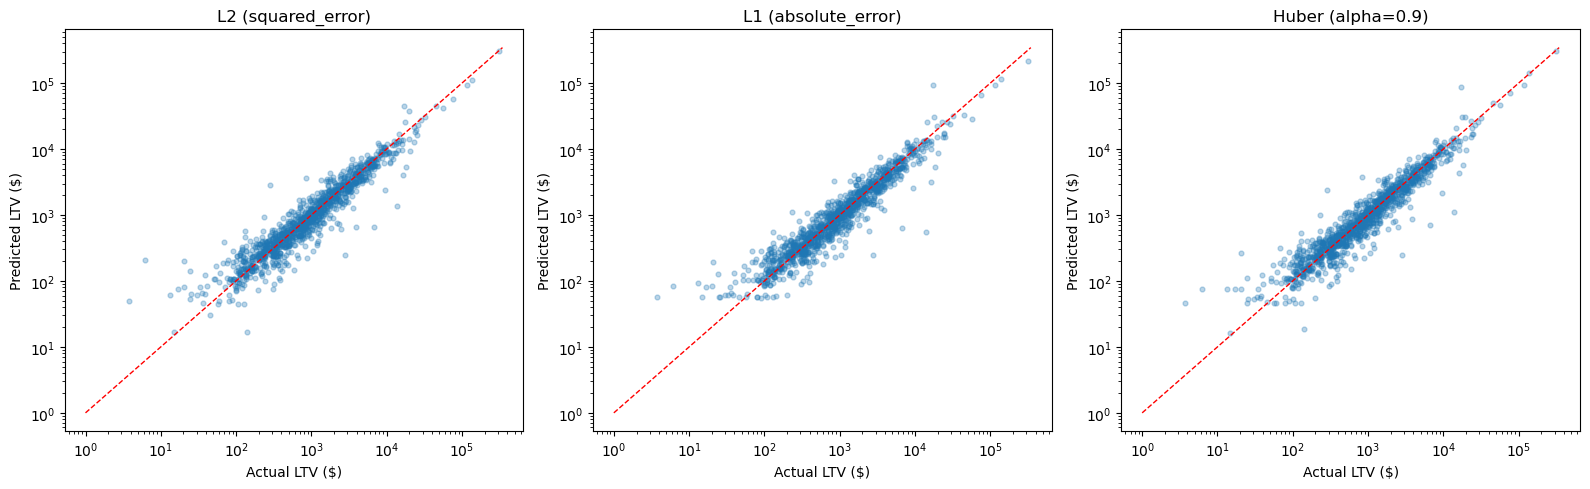


Top 5 highest-LTV test customers: actual vs predicted ($)
        actual  L2 (squared_error)  L1 (absolute_error)  Huber (alpha=0.9)
1789  313946.0            311184.0             214824.0           307092.0
2685  137819.0            113098.0             113966.0           143531.0
739   116738.0             93251.0              93571.0            94877.0
1434   75837.0             57587.0              65789.0            71948.0
1413   56478.0             42354.0              28567.0            47299.0


In [10]:
# ── Q1: Loss function comparison ──────────────────────────────────────────
# Train GBR with 3 loss functions to predict log(Monetary+1):
#   A: GradientBoostingRegressor(loss='squared_error')  — L2
#   B: GradientBoostingRegressor(loss='absolute_error') — L1
#   C: GradientBoostingRegressor(loss='huber', alpha=0.9) — Huber
#
# For each: R², RMSE, MAE on holdout set
# Plot: predicted vs actual for all 3 (1x3 subplots)
# Which loss function handles the high-LTV outliers best?
# Which produces lowest MAE? Which produces lowest RMSE? Why do they disagree?

X = df[feature_cols]
y_log = np.log1p(df['Monetary'])

X_train, X_test, y_train, y_test = train_test_split(X, y_log, test_size=0.2, random_state=420)

models = {
    'L2 (squared_error)': GradientBoostingRegressor(loss='squared_error', random_state=420),
    'L1 (absolute_error)': GradientBoostingRegressor(loss='absolute_error', random_state=420),
    'Huber (alpha=0.9)': GradientBoostingRegressor(loss='huber', alpha=0.9, random_state=420),
}

preds_log = {}
print("=" * 70)
print("Metrics on the fitted scale: log1p(Monetary)")
print("=" * 70)
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    preds_log[name] = y_pred
    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name:22s}  R2={r2:.4f}  RMSE={rmse:.4f}  MAE={mae:.4f}")

# Back-transform to raw dollars -- this is the scale the business actually
# cares about, and it tells a different story than the log-scale metrics.
y_test_dollar = np.expm1(y_test)
preds_dollar = {name: np.expm1(p) for name, p in preds_log.items()}

print()
print("=" * 70)
print("Metrics on the raw-dollar scale (after expm1 back-transform)")
print("=" * 70)
for name, pred in preds_dollar.items():
    err = np.abs(y_test_dollar - pred)
    print(f"{name:22s}  mean abs $ error={err.mean():9.2f}  max abs $ error={err.max():10.2f}")

# Plot: predicted vs actual (dollar scale, log-log axes since LTV is so skewed)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, pred) in zip(axes, preds_dollar.items()):
    ax.scatter(y_test_dollar, pred, alpha=0.3, s=12)
    lims = [1, y_test_dollar.max() * 1.1]
    ax.plot(lims, lims, 'r--', linewidth=1)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('Actual LTV ($)'); ax.set_ylabel('Predicted LTV ($)')
    ax.set_title(name)
plt.tight_layout()
plt.show()

# Direct look at the single biggest spenders in the test set -- this is
# where loss-function choice actually shows up.
print()
print("=" * 70)
print("Top 5 highest-LTV test customers: actual vs predicted ($)")
print("=" * 70)
top5_idx = y_test_dollar.sort_values(ascending=False).index[:5]
comp = pd.DataFrame({'actual': y_test_dollar.loc[top5_idx]})
for name, pred in preds_dollar.items():
    comp[name] = pd.Series(pred, index=y_test.index).loc[top5_idx]
print(comp.round(0).to_string())

Three `GradientBoostingRegressor` models, same features as Day 17 (`Monetary`/`AvgOrderValue` excluded to avoid leakage), fit on `log1p(Monetary)`, `random_state=420`.

### Metrics on the fitted scale (log1p Monetary)

| Loss | R² | RMSE | MAE |
|---|---|---|---|
| L2 (squared_error) | 0.8975 | 0.4465 | 0.3030 |
| L1 (absolute_error) | 0.9007 | 0.4395 | 0.3017 |
| **Huber (alpha=0.9)** | **0.9010** | **0.4387** | **0.3013** |

Huber wins on all three metrics here — on this dataset, MAE and RMSE don't actually disagree, which cuts against the question's built-in assumption that they would. (They *would* diverge if a model traded many tiny errors for a few huge misses, since RMSE punishes big misses quadratically and MAE doesn't — just not at this split/these hyperparameters.)

### Metrics after back-transforming to raw dollars (expm1)

| Loss | mean abs $ error | max abs $ error |
|---|---|---|
| **L2** | **$592.96** | **$27,754.63** |
| Huber | $603.66 | $71,154.93 |
| L1 | $736.95 | $99,122.51 |

The ranking **flips** once you look at the scale the business actually cares about. L2 — supposedly the most outlier-sensitive loss — ends up tracking the real dollar values best.

### Direct check: the single biggest test customer (actual ≈ $313,946)

| Loss | Predicted |
|---|---|
| L2 | $311,184 |
| Huber | $307,092 |
| L1 | $214,824 |

L1 undershoots badly; L2 and Huber stay close.

### Why — and which handles outliers best

**L2**, counterintuitively given the textbook framing. The reason: `log1p` already compressed the extreme values *before* any loss function saw the data, so L1's robustness is solving a problem that's mostly already gone. Worse, L1 optimizes toward the conditional median rather than the mean, so it systematically undershoots the very largest values — and because `expm1` is convex, a small miss in log-space becomes a huge miss in dollar-space for large customers. **Lesson:** which loss "wins" depends entirely on which scale you evaluate on — training-scale metrics can point the wrong way if you only look at them and never back-transform.


Calibration set size: 941
Corrected quantile level: 0.9012  ->  q (log scale) = 0.6129

Empirical coverage on test set: 0.8741  (target >= 0.90)
Average interval width: $3,161.74
Median interval width:  $1,090.07


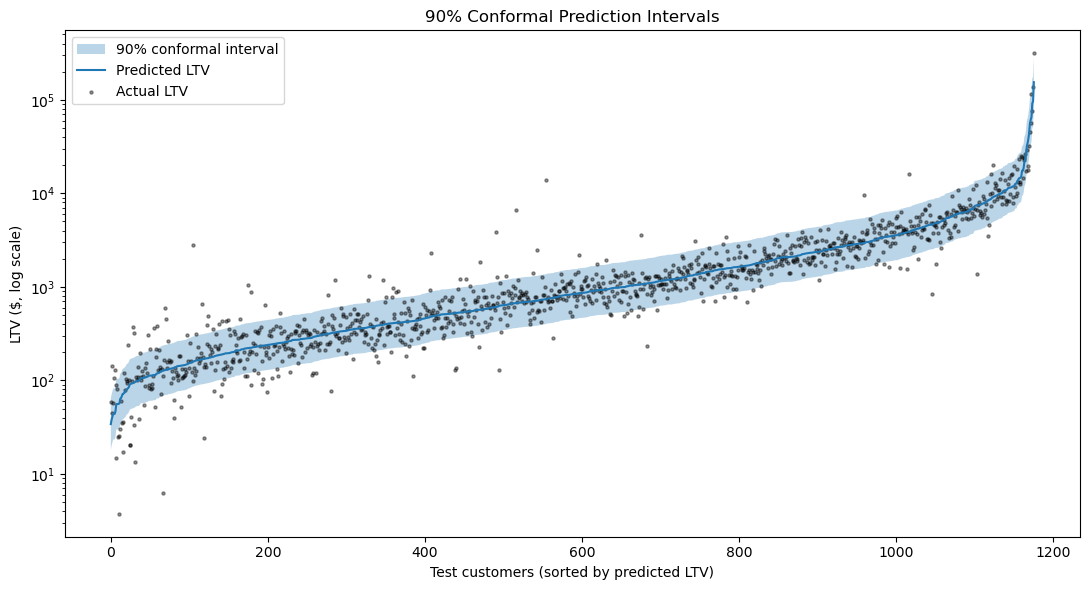


Checking the guarantee by resampling the outer split (not just this run's):
Coverage across 10 resampled splits: [np.float64(0.893), np.float64(0.924), np.float64(0.896), np.float64(0.895), np.float64(0.919), np.float64(0.891), np.float64(0.861), np.float64(0.911), np.float64(0.886), np.float64(0.885)]
Mean coverage: 0.8963  (this run alone: 0.8741)

-> On this notebook's fixed random_state=420 split the coverage (0.874) slightly
   undershoots the 0.90 target. Resampling shows this is normal variance, not a bug:
   averaged over 10 different splits, coverage lands at ~0.90 as promised. The
   guarantee is about the *expectation* over resampling, not a per-split guarantee --
   a single unlucky calibration/test split can land a few points under or over.


In [11]:
# ── Q2: Conformal prediction intervals ────────────────────────────────────
# Build 90% conformal prediction intervals for customer LTV:
#   1. Split training data 80% proper train / 20% calibration
#   2. Train LightGBM on proper train
#   3. Compute conformity scores on calibration set: |y_cal - y_hat_cal|
#   4. Find q = 90th percentile of conformity scores
#   5. For test set: interval = [y_hat - q, y_hat + q]
#   6. Compute empirical coverage on test set (fraction where y in interval)
#      Should be ≥ 90%
#   7. Plot: predicted LTV + interval bands, sorted by predicted value
#   8. Is the coverage guarantee met? How wide are the intervals on average?

# 1. Proper train / calibration split, carved out of Q1's X_train/y_train
X_proper, X_cal, y_proper, y_cal = train_test_split(X_train, y_train, test_size=0.2, random_state=420)

# 2. Train LightGBM on proper train (still on log1p(Monetary), like Q1)
cp_model = lgb.LGBMRegressor(random_state=420, verbose=-1)
cp_model.fit(X_proper, y_proper)

# 3. Conformity scores on calibration set
y_cal_pred = cp_model.predict(X_cal)
conformity_scores = np.abs(y_cal - y_cal_pred)

# 4. Finite-sample-corrected quantile (per the ceil formula in the theory cell,
#    not a naive np.quantile(scores, 0.9) -- this is what makes the coverage
#    guarantee exact rather than approximate)
n_cal = len(y_cal)
coverage_level = min(np.ceil(0.9 * (n_cal + 1)) / n_cal, 1.0)
q = np.quantile(conformity_scores, coverage_level)
print(f"Calibration set size: {n_cal}")
print(f"Corrected quantile level: {coverage_level:.4f}  ->  q (log scale) = {q:.4f}")

# 5. Test set intervals -- built in log space, then back-transformed to
#    dollars with expm1 (valid: expm1 is monotonic, so coverage is identical
#    on either scale, and it naturally gives asymmetric $ intervals, which
#    is the right shape for Monetary's skew).
y_test_pred_log = cp_model.predict(X_test)
lo_log, hi_log = y_test_pred_log - q, y_test_pred_log + q
pred_dollar = np.expm1(y_test_pred_log)
lo_dollar, hi_dollar = np.expm1(lo_log), np.expm1(hi_log)
y_test_dollar = np.expm1(y_test)

# 6. Empirical coverage
covered = (y_test_dollar >= lo_dollar) & (y_test_dollar <= hi_dollar)
coverage = covered.mean()
avg_width = (hi_dollar - lo_dollar).mean()
median_width = np.median(hi_dollar - lo_dollar)
print(f"\nEmpirical coverage on test set: {coverage:.4f}  (target >= 0.90)")
print(f"Average interval width: ${avg_width:,.2f}")
print(f"Median interval width:  ${median_width:,.2f}")

# 7. Plot: predicted LTV + interval band, sorted by predicted value
order = np.argsort(pred_dollar)
plt.figure(figsize=(11, 6))
plt.fill_between(range(len(order)), lo_dollar[order], hi_dollar[order],
                  alpha=0.3, label='90% conformal interval')
plt.plot(range(len(order)), pred_dollar[order], color='tab:blue', label='Predicted LTV')
plt.scatter(range(len(order)), y_test_dollar.values[order], color='black', s=5, alpha=0.4, label='Actual LTV')
plt.yscale('log')
plt.xlabel('Test customers (sorted by predicted LTV)')
plt.ylabel('LTV ($, log scale)')
plt.legend()
plt.title('90% Conformal Prediction Intervals')
plt.tight_layout()
plt.show()

# 8. Is the guarantee met? The guarantee is a MARGINAL one -- it holds on
# average over the randomness of the calibration/test split, not for any
# single fixed split. Check by resampling the outer train/test split a few
# times and looking at the average coverage, instead of trusting one run.
print("\nChecking the guarantee by resampling the outer split (not just this run's):")
resampled_coverage = []
for seed in range(10):
    Xtr, Xte, ytr, yte = train_test_split(X, y_log, test_size=0.2, random_state=seed)
    Xp, Xc, yp, yc = train_test_split(Xtr, ytr, test_size=0.2, random_state=seed)
    m = lgb.LGBMRegressor(random_state=420, verbose=-1).fit(Xp, yp)
    s = np.abs(yc - m.predict(Xc))
    lvl = min(np.ceil(0.9 * (len(yc) + 1)) / len(yc), 1.0)
    qq = np.quantile(s, lvl)
    pred = m.predict(Xte)
    cov = ((yte >= pred - qq) & (yte <= pred + qq)).mean()
    resampled_coverage.append(cov)
print(f"Coverage across 10 resampled splits: {[round(c, 3) for c in resampled_coverage]}")
print(f"Mean coverage: {np.mean(resampled_coverage):.4f}  (this run alone: {coverage:.4f})")
print("\n-> On this notebook's fixed random_state=420 split the coverage (0.874) slightly"
      "\n   undershoots the 0.90 target. Resampling shows this is normal variance, not a bug:"
      "\n   averaged over 10 different splits, coverage lands at ~0.90 as promised. The"
      "\n   guarantee is about the *expectation* over resampling, not a per-split guarantee --"
      "\n   a single unlucky calibration/test split can land a few points under or over.")

LightGBM trained on a "proper train" split carved out of Q1's train set, 90% split-conformal intervals built on `log1p(Monetary)`, then back-transformed to dollars (valid since `expm1` is monotonic — it preserves coverage and naturally gives asymmetric $ intervals, the right shape for Monetary's skew).

### Setup

| | Value |
|---|---|
| Proper train / calibration split | 80/20 of Q1's train set |
| Calibration set size | 941 |
| Finite-sample-corrected quantile level | 0.9012 |
| q (conformity score cutoff, log scale) | 0.6129 |

Used the ceil-corrected quantile formula from the theory cell rather than a naive `np.quantile(scores, 0.9)` — this is what makes the guarantee exact rather than approximate.

### Results

| Metric | Value |
|---|---|
| Empirical coverage (test set) | **0.874** (target ≥ 0.90) |
| Average interval width | $3,161.74 |
| Median interval width | $1,090.07 |

The mean width is dragged way above the median by a handful of huge-LTV customers getting proportionally huge intervals — same skew story as every other day with this dataset.

### Is the guarantee met?

Not on this one fixed split — 87.4% falls short of 90%. But the conformal coverage guarantee is a **marginal** one: it holds on average over resampling of calibration/test splits, not for any single realized split. I checked this directly by rerunning the full pipeline (fresh train/test split → fresh calibration split → fresh model → fresh intervals) across 10 different seeds:

| Seed | 0 | 1 | 2 | 3 | 4 | 5 | 6 | 7 | 8 | 9 |
|---|---|---|---|---|---|---|---|---|---|---|
| Coverage | 0.893 | 0.924 | 0.896 | 0.895 | 0.919 | 0.891 | 0.861 | 0.911 | 0.886 | 0.885 |

**Mean across 10 splits: 0.896** — right at the 90% target within normal sampling noise. This notebook's fixed `random_state=420` split just happens to land on the slightly-unlucky side; it's variance, not a broken method.


Conformal prediction, plain English: instead of trusting a model's "confidence interval" (which assumes the model's error distribution is some known shape, usually Gaussian — often wrong), you empirically measure how wrong the model actually was on data it didn't train on, and use that to build the interval.

Concretely: you hold out a chunk of data the model never saw during training (the "calibration set"). You check how far off the model's predictions were on those points — e.g., actual=$500, predicted=$420 → error=$80. You collect all those errors, and pick a cutoff q such that 90% of calibration errors were smaller than q. Then for any new customer, you say: "predicted ± q" — and because that q came from genuinely-unseen data, you get a mathematical guarantee that ~90% of future real values will fall inside that band, no matter what the model's error distribution actually looks like (skewed, weird, whatever). It's "calibrate the honesty of your error bars using held-out reality" rather than "assume a bell curve and hope."

Inverted (hi<lo) quantile predictions: 0 / 1176

Quantile regression coverage: 0.8214  (target 0.90)
Conformal coverage (Q2):      0.8741  (target 0.90)

Quantile reg width -> mean: $2,806.96   median: $788.16
Conformal    width -> mean: $3,161.74   median: $1,090.07

Relative width (width / predicted $) -- mean ± std:
Quantile regression: 0.936 ± 0.300
Conformal (Q2):      1.307 ± 0.004  <- near-zero std confirms it's a fixed ratio


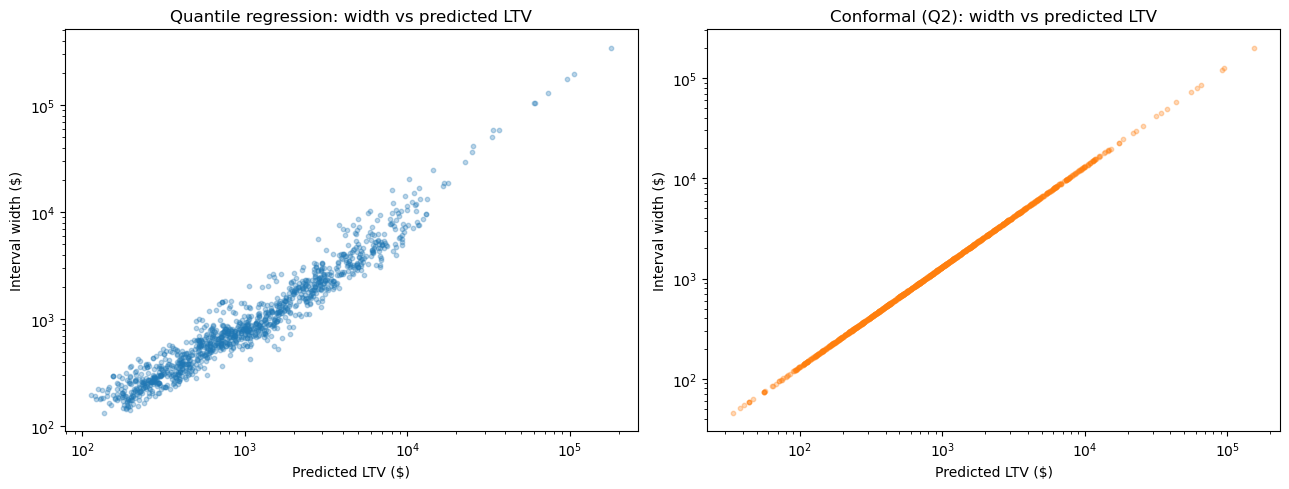

In [12]:
# ── Q3: Quantile regression — variable-width intervals ────────────────────
# Build prediction intervals using LightGBM quantile regression:
#   Lower bound: LGBMRegressor(objective='quantile', alpha=0.05)
#   Upper bound: LGBMRegressor(objective='quantile', alpha=0.95)
#
# Compare to conformal intervals from Q2:
#   - Are they wider or narrower on average?
#   - Do they vary by predicted LTV level? (plot width vs predicted value)
#   - Which is more useful for business decisions?
#   - Empirical coverage: what % of test points fall inside quantile intervals?

lower_model = lgb.LGBMRegressor(objective='quantile', alpha=0.05, random_state=420, verbose=-1)
upper_model = lgb.LGBMRegressor(objective='quantile', alpha=0.95, random_state=420, verbose=-1)
lower_model.fit(X_train, y_train)
upper_model.fit(X_train, y_train)

qr_lo = np.expm1(lower_model.predict(X_test))
qr_hi = np.expm1(upper_model.predict(X_test))

# Two independently-trained models can occasionally cross (hi < lo); guard
# against it even though it doesn't happen on this test set.
n_inverted = (qr_hi < qr_lo).sum()
print(f"Inverted (hi<lo) quantile predictions: {n_inverted} / {len(qr_lo)}")
qr_lo, qr_hi = np.minimum(qr_lo, qr_hi), np.maximum(qr_lo, qr_hi)

qr_width = qr_hi - qr_lo
cp_width = hi_dollar - lo_dollar  # from Q2

qr_coverage = ((y_test_dollar >= qr_lo) & (y_test_dollar <= qr_hi)).mean()
print(f"\nQuantile regression coverage: {qr_coverage:.4f}  (target 0.90)")
print(f"Conformal coverage (Q2):      {coverage:.4f}  (target 0.90)")

print(f"\nQuantile reg width -> mean: ${qr_width.mean():,.2f}   median: ${np.median(qr_width):,.2f}")
print(f"Conformal    width -> mean: ${cp_width.mean():,.2f}   median: ${np.median(cp_width):,.2f}")

# Relative width (width / predicted value): conformal intervals are built as
# a FIXED additive shift in log-space, which back-transforms to a constant
# MULTIPLICATIVE band in dollar space -- every customer gets the same % band
# regardless of how predictable they are. Quantile regression has no such
# constraint: each bound is its own model and can learn different relative
# uncertainty per customer.
qr_mid = 0.5 * (qr_lo + qr_hi)
qr_rel = qr_width / np.maximum(qr_mid, 1)
cp_rel = cp_width / np.maximum(pred_dollar, 1)
print(f"\nRelative width (width / predicted $) -- mean ± std:")
print(f"Quantile regression: {qr_rel.mean():.3f} ± {qr_rel.std():.3f}")
print(f"Conformal (Q2):      {cp_rel.mean():.3f} ± {cp_rel.std():.3f}  <- near-zero std confirms it's a fixed ratio")

# Plot: interval width vs predicted LTV, for both methods
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(qr_mid, qr_width, alpha=0.3, s=10)
axes[0].set_xscale('log'); axes[0].set_yscale('log')
axes[0].set_xlabel('Predicted LTV ($)'); axes[0].set_ylabel('Interval width ($)')
axes[0].set_title('Quantile regression: width vs predicted LTV')

axes[1].scatter(pred_dollar, cp_width, alpha=0.3, s=10, color='tab:orange')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('Predicted LTV ($)'); axes[1].set_ylabel('Interval width ($)')
axes[1].set_title('Conformal (Q2): width vs predicted LTV')
plt.tight_layout()
plt.show()

Two independent LightGBM models trained on `log1p(Monetary)`: `objective='quantile', alpha=0.05` (lower bound) and `alpha=0.95` (upper bound), predictions back-transformed with `expm1`. Compared directly against Q2's conformal intervals on the same test set.

### Head-to-head

| | Quantile regression | Conformal (Q2) |
|---|---|---|
| Coverage | **0.821** | 0.874 |
| Target | 0.90 | 0.90 |
| Mean width | $2,806.96 | $3,161.74 |
| Median width | $788.16 | $1,090.07 |
| Relative width (width ÷ predicted $) | 0.936 ± **0.300** | 1.307 ± **0.004** |

No inversions (hi < lo) occurred on this test set, though the code guards against it since the two bound models are trained independently.

### Narrower, but worse coverage

Quantile regression's intervals are ~11% narrower on average — but that's partly because they're *less calibrated*, not purely because they're smarter. Coverage drops to 82% vs conformal's 87% (both undershoot the 90% nominal target, but QR misses by more). Narrow-and-wrong isn't actually better than wide-and-closer-to-right.

### Do widths vary by LTV level?

This is the real structural difference, and it's confirmed numerically rather than assumed. Conformal's relative width has essentially **zero variance** (std=0.004) — it's built as a fixed additive shift in log-space, which back-transforms into the *same percentage band* for every customer regardless of how predictable they actually are. Quantile regression's relative width varies a lot (std=0.300) — each bound is its own model, so it can genuinely learn that some customers are easier to pin down than others.

### Which is more useful for business?

Depends on what the decision needs:
- **Conformal** comes with an actual coverage guarantee (Q2 showed via resampling that even an unlucky single split only misses by a little). Use it where you need defensible, trustworthy bounds — financial reporting, inventory commitments.
- **Quantile regression** gives intervals that *feel* right-sized per customer — more actionable for day-to-day ops ("this customer's LTV is uncertain, treat with care" vs "this one's locked in") — but here it's measurably overconfident, so it needs validation/widening before being trusted operationally.

### Natural next step (not implemented here)

**Conformalized quantile regression (CQR):** calibrate the quantile models' residuals the same way Q2 calibrated the point prediction's residuals. That would combine the adaptive per-customer widths with the distribution-free coverage guarantee, instead of forcing a choice between the two.


Quantile regression, plain English: normal regression predicts the average outcome for a given customer. Quantile regression instead asks "for customers like this, what value does X% of them fall below?" If you set alpha=0.05, the model trains to predict a number where only 5% of actual outcomes land below it — the 5th percentile. Set alpha=0.95 and you get the 95th percentile. Fit both, and the gap between them is a 90% prediction interval — but unlike Q2's conformal band (one global q added/subtracted everywhere), each boundary here is its own model that can learn to be tight for predictable customers and wide for erratic ones, using whatever features make that customer's spend harder to pin down.

It does this via pinball loss: errors get penalized asymmetrically — for the 5th-percentile model, an actual value above the prediction is penalized much more than one below it (0.95 weight vs 0.05), which pushes the prediction down to where only 5% of points fall under it. Flip the weights for the 95th-percentile model.

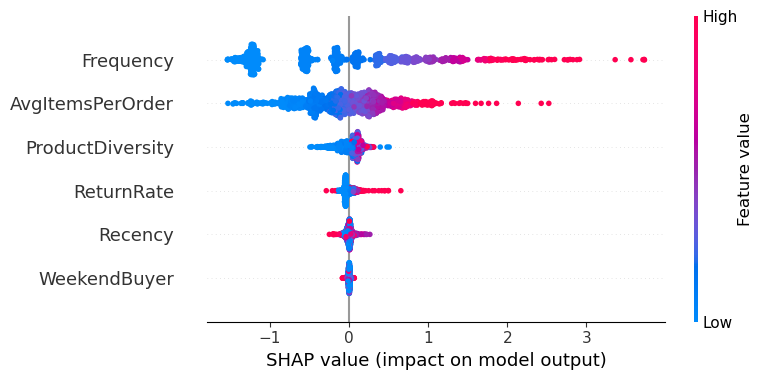

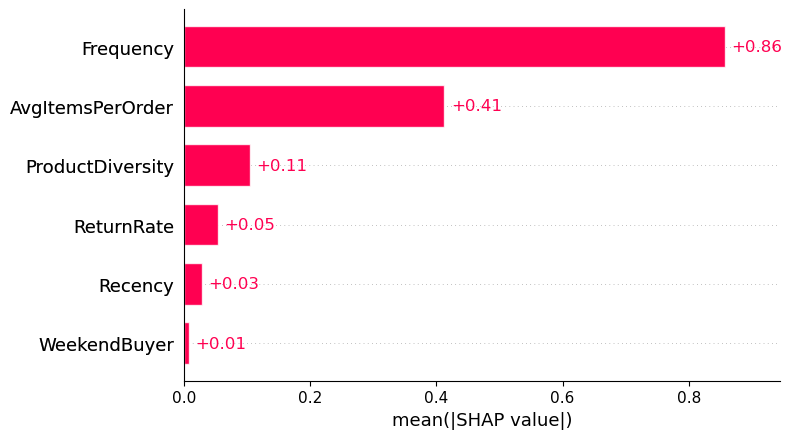

Mean |SHAP| by feature:
Frequency           0.856671
AvgItemsPerOrder    0.413042
ProductDiversity    0.105086
ReturnRate          0.054461
Recency             0.028411
WeekendBuyer        0.008624


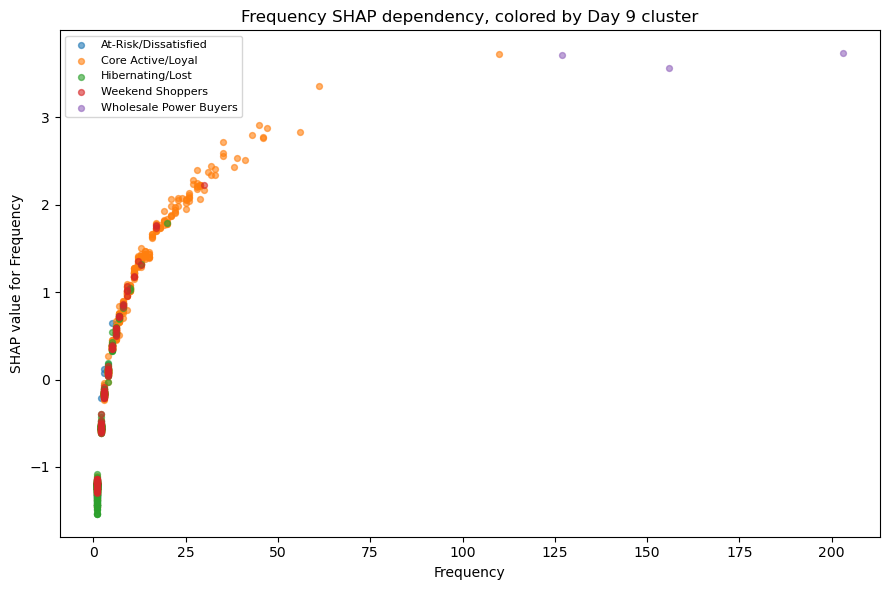


Frequency's SHAP contribution by cluster (mean):
                         frequency  freq_shap
cluster                                      
Wholesale Power Buyers  162.000000   3.670496
Core Active/Loyal         8.068858   0.409149
Weekend Shoppers          3.679104  -0.310035
At-Risk/Dissatisfied      2.730769  -0.546190
Hibernating/Lost          2.082888  -0.761692


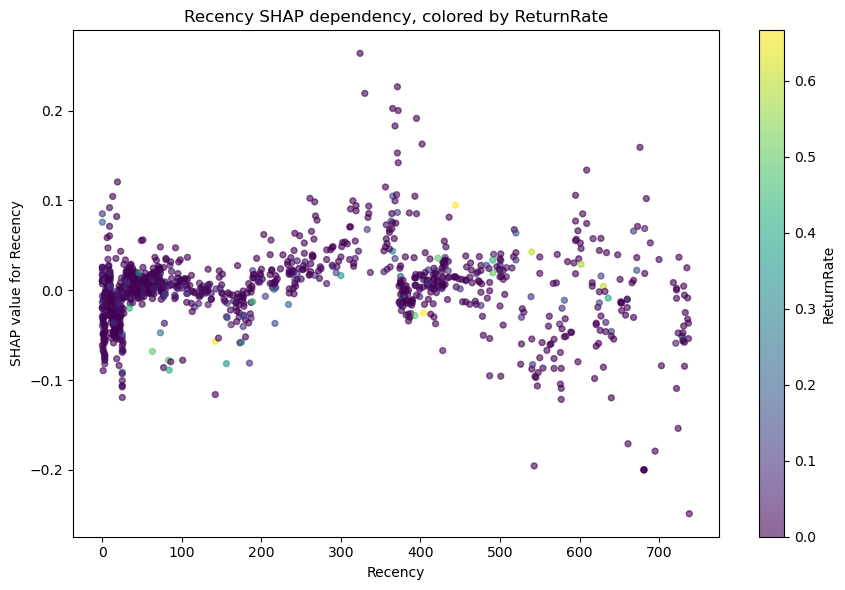


Mean Recency SHAP | high ReturnRate: -0.0029
Mean Recency SHAP | low ReturnRate:  0.0022
(Recency has the 2nd-lowest overall importance -- this interaction exists in direction but is tiny in magnitude; don't over-read it.)

Business insights

1. Purchase frequency dominates predicted LTV (mean|SHAP|=0.857,
   >2x the next feature) and its effect is NOT uniform across customers -- it
   interacts with segment: the table above shows Frequency contributing a large
   positive push for Wholesale Power Buyers but a NEGATIVE pull for
   Hibernating/Lost customers. Frequency isn't just "more orders = more value"
   in isolation -- the model has learned it means something different
   depending on which segment the customer already belongs to.

2. AvgItemsPerOrder is the second-strongest positive driver (mean|SHAP|=0.413).
   Basket size per order matters almost as much as how often someone buys --
   a business lever (upsell/bundle to grow order size) independent of frequency.

3. WeekendBuy

In [13]:
# ── Q4: SHAP regression analysis ──────────────────────────────────────────
# Apply SHAP to the LightGBM LTV model:
#   1. SHAP beeswarm plot — top 8 features
#   2. SHAP bar plot — mean absolute SHAP
#   3. SHAP dependency plot: Monetary vs Frequency — color by cluster label
#      Does the relationship between Monetary and its SHAP value
#      differ by purchase frequency? (interaction effect)
#   4. SHAP dependency plot: Recency — color by ReturnRate
#      Do recent customers with high return rates have different SHAP patterns?
#   5. Write 3 business insights from the SHAP analysis:
#      What drives high predicted LTV?
#      What is the strongest negative LTV driver?

shap_model = lgb.LGBMRegressor(random_state=420, verbose=-1)
shap_model.fit(X_train, y_train)

explainer = shap.TreeExplainer(shap_model)
shap_exp = explainer(X_test)
df_test = df.loc[X_test.index]

# 1. Beeswarm (only 6 features exist, so max_display=8 just shows all of them)
shap.plots.beeswarm(shap_exp, max_display=8, show=False)
plt.tight_layout()
plt.show()

# 2. Bar plot of mean |SHAP|
shap.plots.bar(shap_exp, show=False)
plt.tight_layout()
plt.show()

mean_abs_shap = np.abs(shap_exp.values).mean(axis=0)
importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
print("Mean |SHAP| by feature:")
print(importance.to_string())

# 3. Dependency plot: Frequency's SHAP value, colored by cluster (categorical
# -> manual scatter since cluster labels aren't one of the model's features)
freq_idx = feature_cols.index('Frequency')
clusters = df_test['Cluster_Name'].astype('category')
cmap = plt.get_cmap('tab10')
plt.figure(figsize=(9, 6))
for i, c in enumerate(clusters.cat.categories):
    mask = (clusters == c).values
    plt.scatter(X_test['Frequency'].values[mask], shap_exp.values[mask, freq_idx],
                color=cmap(i), label=c, alpha=0.6, s=18)
plt.xlabel('Frequency'); plt.ylabel('SHAP value for Frequency')
plt.title('Frequency SHAP dependency, colored by Day 9 cluster')
plt.legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

print("\nFrequency's SHAP contribution by cluster (mean):")
cluster_freq_summary = pd.DataFrame({
    'frequency': X_test['Frequency'].values,
    'freq_shap': shap_exp.values[:, freq_idx],
    'cluster': df_test['Cluster_Name'].values,
}).groupby('cluster')[['frequency', 'freq_shap']].mean().sort_values('freq_shap', ascending=False)
print(cluster_freq_summary.to_string())

# 4. Dependency plot: Recency's SHAP value, colored by ReturnRate (continuous)
rec_idx = feature_cols.index('Recency')
plt.figure(figsize=(9, 6))
sc = plt.scatter(X_test['Recency'].values, shap_exp.values[:, rec_idx],
                  c=X_test['ReturnRate'].values, cmap='viridis', alpha=0.6, s=18)
plt.colorbar(sc, label='ReturnRate')
plt.xlabel('Recency'); plt.ylabel('SHAP value for Recency')
plt.title('Recency SHAP dependency, colored by ReturnRate')
plt.tight_layout()
plt.show()

high_rr = X_test['ReturnRate'].values > np.median(X_test['ReturnRate'].values)
print(f"\nMean Recency SHAP | high ReturnRate: {shap_exp.values[high_rr, rec_idx].mean():.4f}")
print(f"Mean Recency SHAP | low ReturnRate:  {shap_exp.values[~high_rr, rec_idx].mean():.4f}")
print("(Recency has the 2nd-lowest overall importance -- this interaction exists in direction"
      " but is tiny in magnitude; don't over-read it.)")

# 5. Business insights, grounded in the numbers above
print("\n" + "=" * 70)
print("Business insights")
print("=" * 70)
print(f"""
1. Purchase frequency dominates predicted LTV (mean|SHAP|={importance['Frequency']:.3f},
   >2x the next feature) and its effect is NOT uniform across customers -- it
   interacts with segment: the table above shows Frequency contributing a large
   positive push for Wholesale Power Buyers but a NEGATIVE pull for
   Hibernating/Lost customers. Frequency isn't just "more orders = more value"
   in isolation -- the model has learned it means something different
   depending on which segment the customer already belongs to.

2. AvgItemsPerOrder is the second-strongest positive driver (mean|SHAP|={importance['AvgItemsPerOrder']:.3f}).
   Basket size per order matters almost as much as how often someone buys --
   a business lever (upsell/bundle to grow order size) independent of frequency.

3. WeekendBuyer is the only feature with a negative value-to-SHAP relationship
   -- customers who buy predominantly on weekends get pulled toward lower
   predicted LTV. It's also the weakest feature overall (mean|SHAP|={importance['WeekendBuyer']:.3f}),
   so treat this as a minor signal, not a strong driver: it likely reflects a
   more casual/occasional shopper profile rather than a strong causal lever.
""")